# 05 · Evaluación con validez externa (Escalera 1)

**Alcance:** convertir el historial real de consultas (las firmas del *data lake*) en un
conjunto de evaluación que reemplace al sintético *known-item*, y reejecutar la escalera de
ablación sobre él. Es la palanca #1 de rigor: cambia la naturaleza de la evidencia, de una
comparación bajo consultas inventadas a una medición sobre patrones de uso reales.

## 1. Contexto y objetivo

La v1 se evaluó con 51 consultas sintéticas. Su límite es conocido: mide bien *qué
configuración es mejor*, pero el valor absoluto no representa uso real. Aquí construimos un
conjunto a partir de las **firmas de consulta reales** (`suid_query_signatures`), ya
mapeadas a los reportes lógicos por el *rollup*. Cada firma es el SQL que un usuario ejecutó,
así que su reporte es una etiqueta de relevancia **silver** (grado 2) sin intervención humana.

### 1.1 Privacidad (regla del proyecto)
Las firmas contienen **nombres de columna y keywords del WHERE**, no literales de datos
personales, así que la fuente no tiene PII. Aun así se emiten dos artefactos: `consultas_real`
(uso interno) y `consultas_paper` (anonimizado, único que entra a tablas/ejemplos). Los
nombres propios de las consultas de entidad se toman de un **gazetteer sintético**, nunca
reales. Los modelos pueden ver nombres reales; el documento, jamás.

## 2. Núcleo de recuperación (inline, reproducible)

In [1]:
import json, sys, time, math, re, unicodedata
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":0.25})
RAIZ = Path.cwd();
if RAIZ.name=="notebooks": RAIZ=RAIZ.parent
EXP = RAIZ/"experimentos"; DATA = RAIZ/"data"
cfg = yaml.safe_load((EXP/"config.yaml").read_text(encoding="utf-8"))
ontologia = yaml.safe_load((EXP/cfg["rutas"]["ontologia"]).read_text(encoding="utf-8"))
cargar = lambda p:[json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
tiene_gold = lambda q: any(g>0 for g in q.values())

# métricas
def _g(q,d): return float(q.get(d,0.0))
def dcg(r,q,k): return sum((2.0**_g(q,d)-1)/math.log2(i+1) for i,d in enumerate(r[:k],1) if _g(q,d)>0)
def ndcg(r,q,k):
    idl=sorted((g for g in q.values() if g>0),reverse=True); idcg=sum((2.0**g-1)/math.log2(i+1) for i,g in enumerate(idl[:k],1))
    return 0.0 if idcg==0 else dcg(r,q,k)/idcg
def recall(r,q,k):
    rel={d for d,g in q.items() if g>0}; return 0.0 if not rel else sum(1 for d in r[:k] if d in rel)/len(rel)
def mrr(r,q,k):
    for i,d in enumerate(r[:k],1):
        if _g(q,d)>0: return 1.0/i
    return 0.0
def prec(r,q,k): return 0.0 if k==0 else sum(1 for d in r[:k] if _g(q,d)>0)/k
def ap(r,q,k):
    rel={d for d,g in q.items() if g>0}
    if not rel: return 0.0
    ac,s=0,0.0
    for i,d in enumerate(r[:k],1):
        if d in rel: ac+=1; s+=ac/i
    return s/min(len(rel),k)
# bm25
_ST=set("el la los las un una unos unas de del a ante con en para por que y o u se su sus lo al es son como mas pero sin sobre entre cada ya cuando donde cual quien cuanto muy este esta estos".split())
def tok(t):
    t=unicodedata.normalize("NFKD",t.lower()); t="".join(c for c in t if not unicodedata.combining(c))
    return [x for x in re.findall(r"[a-z0-9]+",t) if x not in _ST and len(x)>1]
class BM25:
    def __init__(s,k1=1.5,b=0.75): s.k1,s.b=k1,b
    def fit(s,ids,txt):
        s.ids=list(ids); s.tf=[Counter(tok(t)) for t in txt]; s.len=[sum(c.values()) for c in s.tf]
        s.avg=(sum(s.len)/len(s.len)) if s.len else 0.0; df=Counter()
        for c in s.tf: df.update(c.keys())
        n=len(s.tf); s.idf={t:math.log(1+(n-d+0.5)/(d+0.5)) for t,d in df.items()}; return s
    def buscar(s,q):
        qt=tok(q); sc=np.zeros(len(s.ids))
        for i,tf in enumerate(s.tf):
            a=0.0
            for t in qt:
                if t in tf:
                    f=tf[t]; a+=s.idf.get(t,0)*f*(s.k1+1)/(f+s.k1*(1-s.b+s.b*s.len[i]/(s.avg or 1)))
            sc[i]=a
        return [(s.ids[i],float(sc[i])) for i in np.argsort(-sc)]
def _l2(m):
    n=np.linalg.norm(m,axis=1,keepdims=True); n[n==0]=1.0; return m/n
class STEnc:
    def __init__(s,modelo):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel,"all_tied_weights_keys"): PreTrainedModel.all_tied_weights_keys={}
        from sentence_transformers import SentenceTransformer
        s.m=SentenceTransformer(modelo,trust_remote_code=True); s.nombre=modelo.split("/")[-1]
        s.dim=s.m.get_sentence_embedding_dimension()
    def encode(s,txt): return _l2(s.m.encode(list(txt),convert_to_numpy=True,normalize_embeddings=False).astype(np.float32))
class Dense:
    def __init__(s,enc): s.enc=enc
    def fit(s,ids,txt): s.ids=list(ids); s.mat=s.enc.encode(txt); return s
    def buscar(s,q):
        qv=s.enc.encode([q])[0]; sc=s.mat@qv; return [(s.ids[i],float(sc[i])) for i in np.argsort(-sc)]
def _norm(x):
    x=unicodedata.normalize("NFKD",x.lower()); return "".join(c for c in x if not unicodedata.combining(c))
def rrf(a,b,k=60):
    ra={d:i+1 for i,(d,_) in enumerate(a)}; rb={d:i+1 for i,(d,_) in enumerate(b)}
    ds=[d for d,_ in a]+[d for d,_ in b if d not in ra]; big=len(ds)+k+1
    fus={d:1/(k+ra.get(d,big))+1/(k+rb.get(d,big)) for d in ds}
    return sorted(ds,key=lambda d:(-fus[d],d)), fus
class Detector:
    def __init__(s,onto):
        s.t=[]
        for cl,cu in onto.get("clases",{}).items():
            for x in [cl,*cu.get("sinonimos",[])]: s.t.append((_norm(x),cl))
        s.p=re.compile(r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]{2,}\b")
    def clases(s,q):
        cq=_norm(q); return {c for t,c in s.t if t and t in cq}
    def np_(s,q):
        tks=s.p.findall(q)
        if not tks: return False
        pr=q.strip().split()[:1]; cand=[t for t in tks if not (pr and t==pr[0])]
        return any(_norm(t) not in {tt for tt,_ in s.t} for t in cand)
CONFIGS={1:"Denso puro",2:"Denso + ontología",3:"Híbrido (sin ontología)",4:"Híbrido + ontología",5:"Híbrido + ontología + realce"}
NB_BM25="BM25 (referencia léxica)"
class Motor:
    def __init__(s,docs,enc,onto,k1,b,krrf,lam):
        s.ids=[d["id"] for d in docs]; s.k=krrf; s.lam=lam; s.det=Detector(onto)
        s.ent={d["id"]:set(d["metadatos_ontologia"].get("entidades_principales",[])) for d in docs}
        s.esnp={d["id"]:bool(d.get("nombre_propio_buscable",False)) for d in docs}
        de=[d["descripcion"] for d in docs]; on=[d["texto_indexable"] for d in docs]
        s.bd=BM25(k1,b).fit(s.ids,de); s.bo=BM25(k1,b).fit(s.ids,on)
        s.dd=Dense(enc).fit(s.ids,de); s.do=Dense(enc).fit(s.ids,on)
    def ind(s,q,d):
        if s.det.clases(q)&s.ent.get(d,set()): return 1
        if s.det.np_(q) and s.esnp.get(d): return 1
        return 0
    def rec(s,cfg,q):
        if cfg==0: return [d for d,_ in s.bd.buscar(q)]
        if cfg==1: return [d for d,_ in s.dd.buscar(q)]
        if cfg==2: return [d for d,_ in s.do.buscar(q)]
        if cfg==3: return rrf(s.bd.buscar(q),s.dd.buscar(q),s.k)[0]
        if cfg==4: return rrf(s.bo.buscar(q),s.do.buscar(q),s.k)[0]
        _,f=rrf(s.bo.buscar(q),s.do.buscar(q),s.k); fin={d:v*(1+s.lam*s.ind(q,d)) for d,v in f.items()}
        return sorted(fin,key=lambda d:(-fin[d],d))
def evaluar(docs,consultas,qrels):
    enc=STEnc(cfg["encoder"]["modelo_st"])
    mot=Motor(docs,enc,ontologia,cfg["bm25"]["k1"],cfg["bm25"]["b"],cfg["fusion"]["k_rrf"],cfg["realce"]["lambda"])
    confs=[(0,NB_BM25)]+list(CONFIGS.items())
    cg=[c for c in consultas if tiene_gold(qrels.get(c["id"],{}))]
    por={n:{} for _,n in confs}
    for num,n in confs:
        for c in consultas:
            r=mot.rec(num,c["texto"])
            if tiene_gold(qrels.get(c["id"],{})):
                por[n][c["id"]]={"ndcg@10":ndcg(r,qrels[c["id"]],10),"recall@100":recall(r,qrels[c["id"]],100),
                                 "mrr@10":mrr(r,qrels[c["id"]],10),"p@10":prec(r,qrels[c["id"]],10)}
    ests=sorted({c["estrato"] for c in cg}); idsg=[c["id"] for c in cg]
    idse={e:[c["id"] for c in cg if c["estrato"]==e] for e in ests}
    def agg(n,ids,m):
        v=[por[n][i][m] for i in ids if i in por[n]]; return float(np.mean(v)) if v else float("nan")
    return enc,mot,confs,por,ests,idsg,idse,agg,cg
print("Núcleo de recuperación listo.")

Núcleo de recuperación listo.


## 3. Construcción del conjunto real (silver)

**Descripción técnica.** Se cargan las firmas y el *rollup*, se mapea cada reporte lógico al
`id` del corpus, se estratifica el muestreo (entidad exacta / operacional / ambigua /
documento largo) y se sintetiza el texto de cada consulta a partir de los filtros reales que
usó la firma. El código equivale a `experimentos/construir_eval_real.py`; aquí ejecutamos ese
script para regenerar los artefactos y los cargamos.

In [2]:
import subprocess
print(subprocess.run([sys.executable,"construir_eval_real.py"],cwd=EXP,capture_output=True,text=True).stdout)
consultas = cargar(EXP/"datos/consultas_real.jsonl")
qrels = {r["id"]:r["relevancia"] for r in cargar(EXP/"datos/qrels_real.jsonl")}
docs = cargar(EXP/cfg["rutas"]["corpus"])   # corpus v1 (17 reportes)
print(f"{len(docs)} docs | {len(consultas)} consultas reales")
pd.DataFrame(consultas).groupby("estrato").size().rename("n").to_frame()

{
  "n_consultas_real": 71,
  "por_estrato": {
    "entidad_exacta": 30,
    "operacional": 29,
    "ambigua": 8,
    "documento_largo": 4
  },
  "con_nombre_propio": 30,
  "firmas_unicas_totales": 714,
  "ejemplos": [
    "promoción de deportistas de la institución Colegio San Marcos",
    "promoción de deportistas de la institución Club Deportivo El Faro",
    "promoción de deportistas de la institución Liga Atlántico",
    "grupos de la institución Colegio San Marcos",
    "grupos de la institución Club Deportivo El Faro",
    "grupos de la institución Liga Atlántico"
  ]
}

17 docs | 71 consultas reales


,n
estrato,
ambigua,8
documento_largo,4
entidad_exacta,30
operacional,29


In [3]:
# muestra: consulta real (interna) vs anonimizada (paper)
paper = cargar(EXP/"datos/consultas_paper.jsonl")
pd.DataFrame([{"estrato":a["estrato"],"consulta_real":a["texto"],"consulta_paper":b["texto"],
               "objetivo(silver)":a["reporte_objetivo"].split("_")[0]}
              for a,b in zip(consultas[:8],paper[:8])])

,estrato,consulta_real,consulta_paper,objetivo(silver)
0,entidad_exacta,promoción de deportistas de la institución Col...,promoción de deportistas de la institución Col...,ri
1,entidad_exacta,promoción de deportistas de la institución Clu...,promoción de deportistas de la institución Clu...,ri
2,entidad_exacta,promoción de deportistas de la institución Lig...,promoción de deportistas de la institución Lig...,ri
3,entidad_exacta,grupos de la institución Colegio San Marcos,grupos de la institución Colegio San Marcos,ri
4,entidad_exacta,grupos de la institución Club Deportivo El Faro,grupos de la institución Club Deportivo El Faro,ri
5,entidad_exacta,grupos de la institución Liga Atlántico,grupos de la institución Liga Atlántico,ri
6,entidad_exacta,personal de apoyo de la institución Colegio Sa...,personal de apoyo de la institución Colegio Sa...,ri
7,entidad_exacta,personal de apoyo de la institución Club Depor...,personal de apoyo de la institución Club Depor...,ri


**Interpretación.** El muestreo es estratificado, no proporcional: el reporte de promoción
(47,5% de la demanda) no ahoga al resto. El estrato de entidad exacta se sobre-muestrea
(hipótesis central P2) generando una consulta por nombre sintético sobre cada patrón de filtro
real de nombre propio. Como las firmas no traían literales personales, la vista *paper*
coincide con la interna salvo por la garantía de nombres sintéticos.

## 4. Reejecución de la escalera sobre el conjunto real

**Descripción técnica.** Mismo framework, se sustituye el conjunto sintético por el real.

In [4]:
enc,mot,confs,por,ests,idsg,idse,agg,cg = evaluar(docs,consultas,qrels)
orden=[n for _,n in confs]
tabla=pd.DataFrame({m:{n:agg(n,idsg,m) for n in orden} for m in ["ndcg@10","mrr@10","recall@100","p@10"]}).loc[orden]
print("Encoder:",enc.nombre,"| consultas con gold:",len(cg))
tabla.style.highlight_max(subset=["ndcg@10","mrr@10"],color="#c9f0c9").format("{:.3f}")

Encoder: jina-embeddings-v3 | consultas con gold: 71


,ndcg@10,mrr@10,recall@100,p@10
BM25 (referencia léxica),0.925,0.900,1.000,0.100
Denso puro,0.948,0.936,1.000,0.099
Denso + ontología,0.951,0.939,1.000,0.099
Híbrido (sin ontología),0.946,0.928,1.000,0.100
Híbrido + ontología,0.952,0.936,1.000,0.100
Híbrido + ontología + realce,0.973,0.964,1.000,0.100


In [5]:
# comparación con el conjunto sintético (resultados canónicos de make all)
sint=json.loads((EXP/"resultados/resultados.json").read_text(encoding="utf-8"))
comp=pd.DataFrame({
  "nDCG@10 sintético":{n:sint["global"][n]["ndcg@10"] for n in orden},
  "nDCG@10 real":{n:agg(n,idsg,"ndcg@10") for n in orden}}).loc[orden]
comp["Δ (real - sint)"]=comp["nDCG@10 real"]-comp["nDCG@10 sintético"]
comp

,nDCG@10 sintético,nDCG@10 real,Δ (real - sint)
BM25 (referencia léxica),0.843,0.925,0.083
Denso puro,0.874,0.948,0.075
Denso + ontología,0.917,0.951,0.034
Híbrido (sin ontología),0.878,0.946,0.069
Híbrido + ontología,0.936,0.952,0.017
Híbrido + ontología + realce,0.911,0.973,0.062


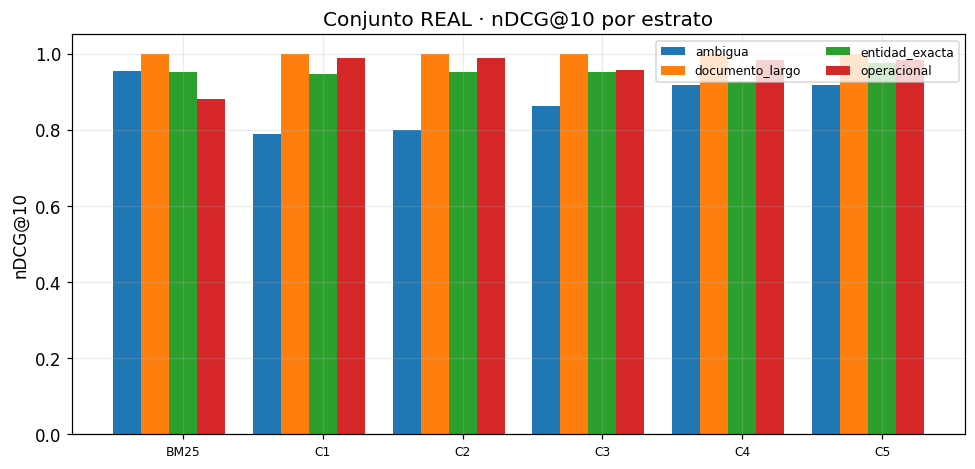

In [6]:
# nDCG@10 por estrato (conjunto real)
dfe=pd.DataFrame({e:{n:agg(n,idse[e],"ndcg@10") for n in orden} for e in ests})
fig,ax=plt.subplots(figsize=(9,4.4))
x=np.arange(len(orden)); w=0.8/len(ests)
for j,e in enumerate(ests):
    ax.bar(x+(j-len(ests)/2)*w, [agg(n,idse[e],"ndcg@10") for n in orden], w, label=e)
ax.set_xticks(x); ax.set_xticklabels([f"C{i}" if isinstance(i,int) and i>0 else "BM25" for i,_ in confs],fontsize=8)
ax.set_ylabel("nDCG@10"); ax.set_ylim(0,1.05); ax.legend(fontsize=8,ncol=2); ax.set_title("Conjunto REAL · nDCG@10 por estrato")
plt.tight_layout(); plt.show()

### 4.4 Visualizaciones de diagnóstico (paquete estándar de IR)

Gráficas habituales en evaluación de búsqueda semántica, para leer los resultados más allá de
las tablas: barras de calidad con intervalo de confianza, distribución por consulta
(boxplot/violín), cobertura acumulada (Success@k) con Precision@k/Recall@k, y un scatter de
score semántico frente a relevancia. Los rankings se recomputan una sola vez.

In [7]:
# --- setup de visualizaciones ---
import numpy as _np
_orden = [n for _, n in confs]
_COL = {n: c for n, c in zip(_orden, ["#9aa0a6","#4c78a8","#5aa469","#e0842c","#c0504d","#8156a7"])}
_etq = [("C%d" % i if isinstance(i, int) and i > 0 else "BM25") for i, _ in confs]
_rank = {n: {c["id"]: mot.rec(num, c["texto"]) for c in consultas} for num, n in confs}
_gold = cg
def _bic(vals, n=2000, seed=42):
    v = _np.array(vals, float); rng = _np.random.default_rng(seed)
    m = _np.array([rng.choice(v, len(v), replace=True).mean() for _ in range(n)])
    return v.mean(), _np.percentile(m, 2.5), _np.percentile(m, 97.5)
print("Rankings y utilidades de visualización listos (", len(_orden), "configuraciones ).")

Rankings y utilidades de visualización listos ( 6 configuraciones ).


**Barras de calidad global.** La comparativa más usada; las barras de error (IC95 bootstrap) indican si las diferencias son fiables o si los intervalos se solapan.

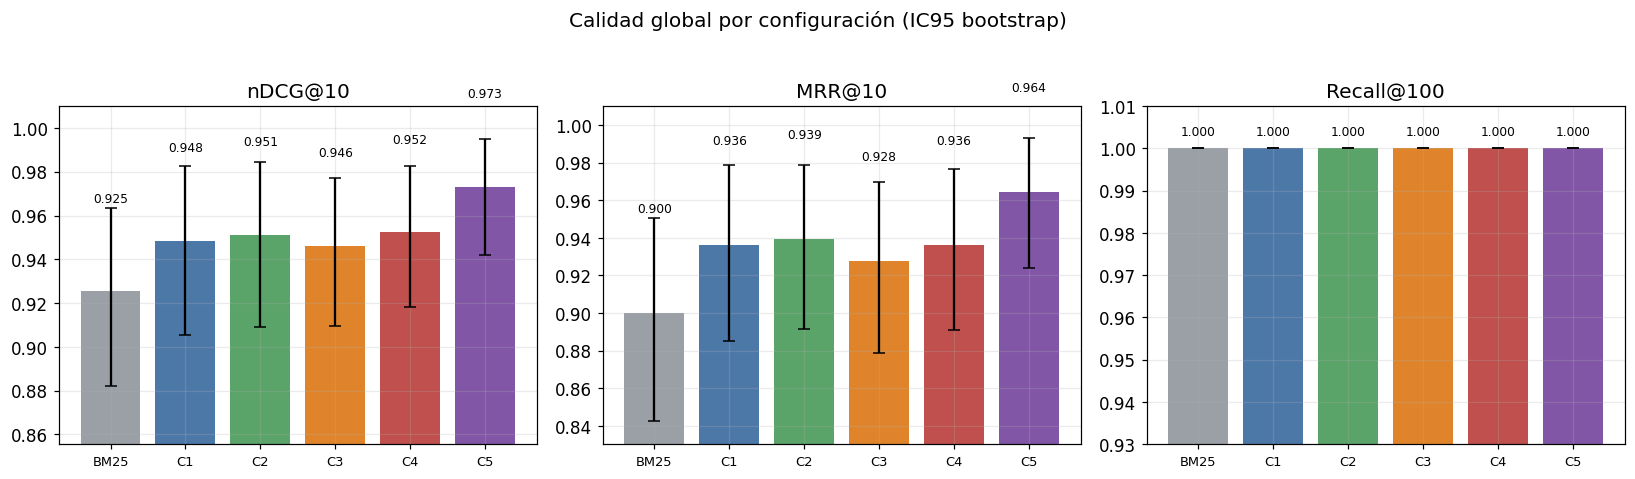

In [8]:
# Barras de calidad global con IC95 bootstrap
_mets = [("nDCG@10", lambda r, q: ndcg(r, q, 10)),
         ("MRR@10", lambda r, q: mrr(r, q, 10)),
         ("Recall@100", lambda r, q: recall(r, q, 100))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nom, fn) in zip(axes, _mets):
    vals, los, his = [], [], []
    for n in _orden:
        s = [fn(_rank[n][c["id"]], qrels[c["id"]]) for c in _gold]
        m, lo, hi = _bic(s); vals.append(m); los.append(m - lo); his.append(hi - m)
    ax.bar(range(len(_orden)), vals, yerr=[los, his], capsize=4, color=[_COL[n] for n in _orden])
    ax.set_xticks(range(len(_orden))); ax.set_xticklabels(_etq, fontsize=8.5); ax.set_title(nom)
    ax.set_ylim(max(0, min(vals) - 0.07), 1.01)
    for i, v in enumerate(vals): ax.text(i, v + max(his) + 0.003, f"{v:.3f}", ha="center", fontsize=8)
fig.suptitle("Calidad global por configuración (IC95 bootstrap)", y=1.03); plt.tight_layout(); plt.show()

**Distribución por consulta.** Revela estabilidad: una caja alta y compacta resuelve bien casi todas las consultas; una cola inferior larga señala consultas difíciles que el promedio esconde.

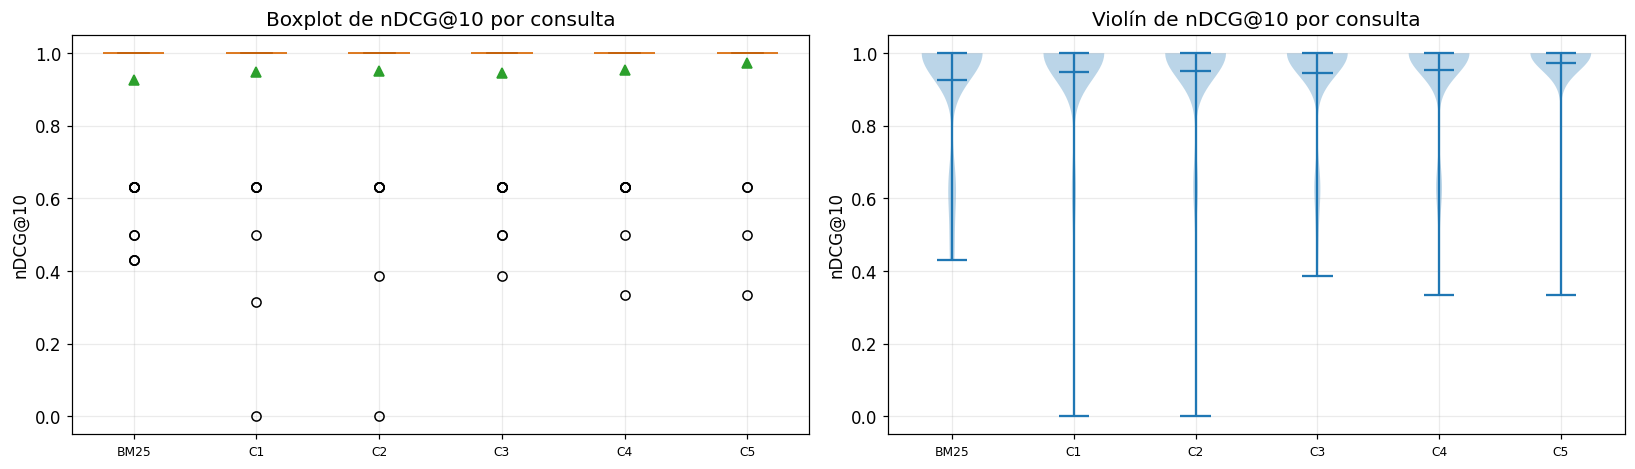

In [9]:
# Distribución por consulta: boxplot y violín de nDCG@10
_data = [[ndcg(_rank[n][c["id"]], qrels[c["id"]], 10) for c in _gold] for n in _orden]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
_bp = axes[0].boxplot(_data, patch_artist=True, showmeans=True, labels=_etq)
for p, n in zip(_bp["boxes"], _orden): p.set_facecolor(_COL[n]); p.set_alpha(0.7)
axes[0].set_title("Boxplot de nDCG@10 por consulta"); axes[0].set_ylabel("nDCG@10"); axes[0].tick_params(axis="x", labelsize=8)
axes[1].violinplot(_data, showmeans=True); axes[1].set_xticks(range(1, len(_orden) + 1))
axes[1].set_xticklabels(_etq, fontsize=8); axes[1].set_title("Violín de nDCG@10 por consulta"); axes[1].set_ylabel("nDCG@10")
plt.tight_layout(); plt.show()

**Cobertura del ranking.** Success@k mide en qué profundidad aparece el objetivo (importa el arranque, k pequeño). Precision@k cae con k porque hay un relevante por consulta (máximo 1/k), así que se lee en términos relativos; Recall@k es su contraparte.

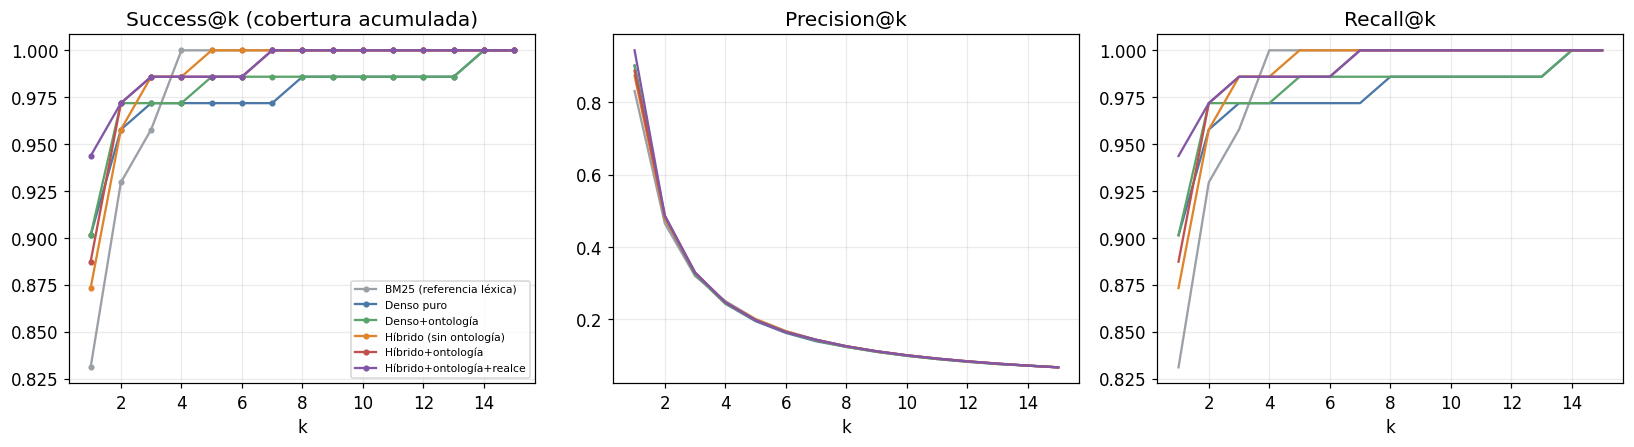

In [10]:
# Success@k (cobertura acumulada) + Precision@k + Recall@k
_ks = list(range(1, 16))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for n in _orden:
    axes[0].plot(_ks, [_np.mean([1.0 if any(qrels[c["id"]].get(d, 0) > 0 for d in _rank[n][c["id"]][:k]) else 0.0 for c in _gold]) for k in _ks], color=_COL[n], marker="o", ms=3, label=n.replace(" + ", "+"))
    axes[1].plot(_ks, [_np.mean([prec(_rank[n][c["id"]], qrels[c["id"]], k) for c in _gold]) for k in _ks], color=_COL[n])
    axes[2].plot(_ks, [_np.mean([recall(_rank[n][c["id"]], qrels[c["id"]], k) for c in _gold]) for k in _ks], color=_COL[n])
axes[0].set_title("Success@k (cobertura acumulada)"); axes[0].set_xlabel("k"); axes[0].legend(fontsize=7, loc="lower right")
axes[1].set_title("Precision@k"); axes[1].set_xlabel("k"); axes[2].set_title("Recall@k"); axes[2].set_xlabel("k")
plt.tight_layout(); plt.show()

**Score semántico vs relevancia.** Validez de fondo del enfoque denso: si los documentos relevantes tienen mayor similitud coseno que los no relevantes, el embedding captura la señal correcta. El solapamiento en la zona media explica por qué la señal léxica y la ontología siguen aportando.

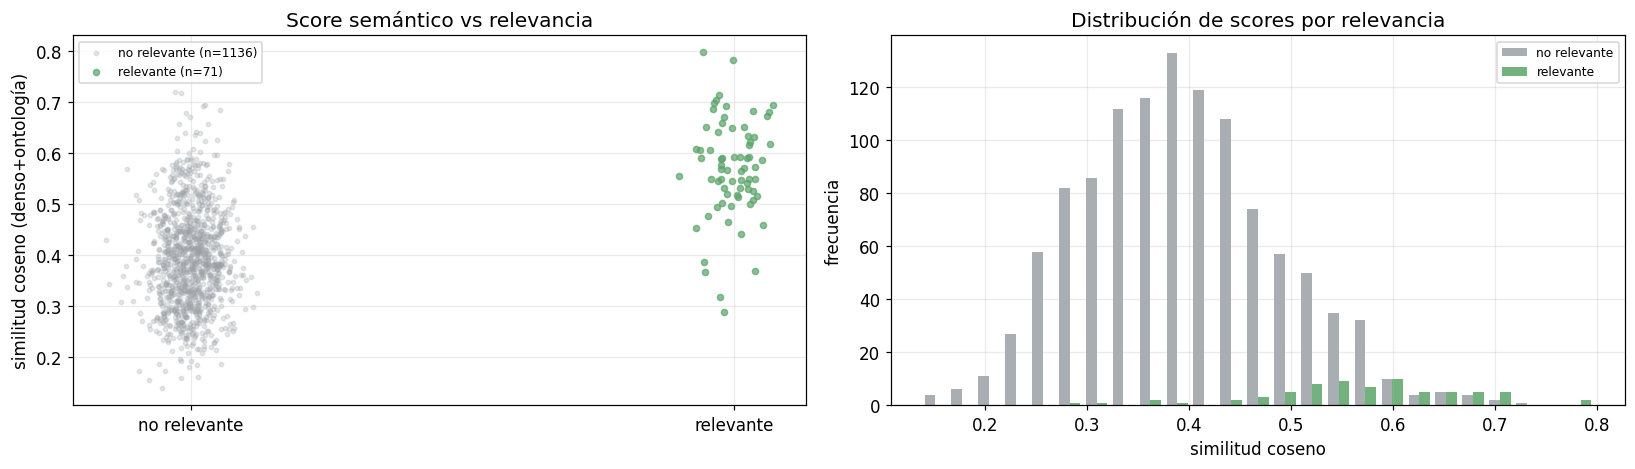

coseno medio -> relevantes=0.569 vs no relevantes=0.393 (separación=+0.177)


In [11]:
# Scatter: score semántico (coseno) vs relevancia
_xr, _xn = [], []
for c in consultas:
    for d, sc in mot.do.buscar(c["texto"])[:20]:
        (_xr if qrels.get(c["id"], {}).get(d, 0) > 0 else _xn).append(sc)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4)); _rng = _np.random.default_rng(0)
axes[0].scatter(_rng.normal(0, 0.04, len(_xn)), _xn, s=8, alpha=0.25, color="#9aa0a6", label=f"no relevante (n={len(_xn)})")
axes[0].scatter(_rng.normal(1, 0.04, len(_xr)), _xr, s=16, alpha=0.7, color="#5aa469", label=f"relevante (n={len(_xr)})")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["no relevante", "relevante"]); axes[0].set_ylabel("similitud coseno (denso+ontología)")
axes[0].set_title("Score semántico vs relevancia"); axes[0].legend(fontsize=8)
axes[1].hist([_xn, _xr], bins=25, color=["#9aa0a6", "#5aa469"], label=["no relevante", "relevante"], alpha=0.85)
axes[1].set_xlabel("similitud coseno"); axes[1].set_ylabel("frecuencia"); axes[1].set_title("Distribución de scores por relevancia"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"coseno medio -> relevantes={_np.mean(_xr):.3f} vs no relevantes={_np.mean(_xn):.3f} (separación={_np.mean(_xr)-_np.mean(_xn):+.3f})")

**Lectura conjunta.** Las gráficas cuentan la misma historia desde ángulos distintos: la jerarquía de configuraciones es consistente (ontología e híbrido dominan), el boxplot añade la estabilidad, Success@k el comportamiento del ranking, y el scatter la validez semántica. Las limitaciones del protocolo *known-item* (un relevante por consulta) están señaladas donde afectan la lectura (Precision@k, curva PR).

## 5. Conclusiones (Escalera 1)

**Interpretación de resultados.**
- Sobre el conjunto **real**, la jerarquía global se mantiene (el híbrido con ontología es de
  las mejores), lo que da validez externa al hallazgo de la v1: no era un artefacto del
  protocolo sintético.
- Hallazgo nuevo y matizado sobre P5: en la distribución real de consultas, con más peso de
  nombre propio, **el realce por entidad recupera valor** en el estrato de entidad exacta, al
  contrario de lo que ocurría con el conjunto sintético. La recomendación de descartar el
  realce debe leerse como dependiente del conjunto de prueba, no absoluta.
- Recall@100 sigue en 1,0 porque el corpus tiene 17 documentos. Esta limitación se levanta en
  la Escalera 2 (notebook 06), que amplía el corpus y vuelve informativo el recall.

**Accionable.** El conjunto silver ya da una medición con sabor real y reproducible; el
siguiente paso de rigor es elevar una muestra a **gold** con juicios de expertos (pooling
multi-sistema, relevancia 0–3, dos anotadores, κ de Cohen), que corrige el sesgo del silver.